# Amazon Sales Forecasting — Modelado, Evaluación y Optimización
**Objetivo:** Mi objetivo es predecir las unidades encargadas del mes siguiente por producto (ASIN).  
**Base:** Utilizo `df_total_limpio.csv` generado en `DatasetAmazon_Corregido.ipynb`.

## 1. Imports

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBRegressor

## 2. Carga del dataset limpio

Cargo el CSV generado por el notebook de preprocesamiento.  
Si la columna `fecha` no existe (el CSV se guardó antes de crearla), la reconstruyo automáticamente.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/DatasetAmazon/df_total_limpio.csv')

# Reconstruir fecha si no existe en el CSV
if 'fecha' not in df.columns:
    meses_a_num = {
        'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,
        'Mayo':5,'Junio':6,'Julio':7,'Agosto':8,
        'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12
    }
    df['fecha'] = pd.to_datetime(
        df['Anio'].astype(str) + '-' +
        df['Mes'].map(meses_a_num).astype(str) + '-01'
    )

df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values(['ASIN (child)', 'fecha']).reset_index(drop=True)

print(f"{len(df):,} filas  |  {df['ASIN (child)'].nunique()} productos cargados.")
print(f"El rango de fechas de los datos es: {df['fecha'].min().date()} hasta {df['fecha'].max().date()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2,683 filas  |  191 productos cargados.
El rango de fechas de los datos es: 2024-04-01 hasta 2026-02-01


## 3. Feature Engineering

Construyo todas las features **dentro de cada ASIN** (`groupby`) para no contaminar productos entre sí.

| Feature | Qué captura |
|---------|------------|
| `lag_1` | Ventas del mes anterior (captura la tendencia inmediata) |
| `lag_2` | Ventas de hace 2 meses (indica aceleración o frenada) |
| `lag_12` | Ventas del mismo mes del año pasado (captura la estacionalidad anual) |
| `ma_3` | Media móvil de 3 meses (ayuda a suavizar el ruido) |
| `ma_6` | Media móvil de 6 meses (refleja la tendencia media) |
| `tasa_conversion` | Unidades / Sesiones (mide la eficiencia de venta) |
| `mes_sin`, `mes_cos` | Estacionalidad cíclica (considerando que enero y diciembre son continuos) |
| `trimestre` | Ofrece un contexto estacional más amplio |

Elimino `Visitas: total` porque es redundante con `Sesiones: total` (correlación > 0.95).

In [6]:
df['Unidades encargadas'] = pd.to_numeric(df['Unidades encargadas'], errors='coerce')
df['Sesiones: total']     = pd.to_numeric(df['Sesiones: total'],     errors='coerce')

g = df.groupby('ASIN (child)')

df['lag_1']  = g['Unidades encargadas'].shift(1)
df['lag_2']  = g['Unidades encargadas'].shift(2)
df['lag_12'] = g['Unidades encargadas'].shift(12)

df['ma_3'] = g['Unidades encargadas'].transform(lambda x: x.shift(1).rolling(3).mean())
df['ma_6'] = g['Unidades encargadas'].transform(lambda x: x.shift(1).rolling(6).mean())

df['tasa_conversion'] = df['Unidades encargadas'] / df['Sesiones: total'].replace(0, np.nan)

df['mes_num']   = df['fecha'].dt.month
df['mes_sin']   = np.sin(2 * np.pi * df['mes_num'] / 12)
df['mes_cos']   = np.cos(2 * np.pi * df['mes_num'] / 12)
df['trimestre'] = df['fecha'].dt.quarter

# Target: unidades del MES SIGUIENTE
df['target_t1'] = g['Unidades encargadas'].shift(-1)

feature_cols = [
    'lag_1', 'lag_2', 'lag_12',
    'ma_3', 'ma_6',
    'tasa_conversion', 'Sesiones: total',
    'mes_sin', 'mes_cos', 'trimestre'
]

df_model = df.dropna(subset=feature_cols + ['target_t1']).copy()
print(f"Filas útiles para el modelo: {len(df_model):,}  |  Productos únicos: {df_model['ASIN (child)'].nunique()}")

Filas útiles para el modelo: 817  |  Productos únicos: 96


## 4. Partición Train / Test — Split Temporal

Realizo una partición temporal, nunca aleatoria. Un split aleatorio en series temporales podría filtrar información del futuro al pasado (data leakage).  
Los últimos **3 meses** los asigno al conjunto de test, el resto al de train.

In [7]:
fecha_corte = df_model['fecha'].max() - pd.DateOffset(months=3)

train = df_model[df_model['fecha'] <= fecha_corte].copy()
test  = df_model[df_model['fecha'] >  fecha_corte].copy()

X_train, y_train = train[feature_cols], train['target_t1']
X_test,  y_test  = test[feature_cols],  test['target_t1']

print(f"TRAIN: {len(train):,} filas  |  {train['fecha'].min().date()} → {train['fecha'].max().date()}")
print(f"TEST:  {len(test):,}  filas  |  {test['fecha'].min().date()}  → {test['fecha'].max().date()}")


TRAIN: 558 filas  |  2025-03-01 → 2025-10-01
TEST:  259  filas  |  2025-11-01  → 2026-01-01


## 5. Baseline Naive

Establezco una referencia mínima obligatoria: "el mes que viene venderé lo mismo que este mes".  
Si mi modelo XGBoost no supera este baseline, significa que no aporta valor.

In [8]:
y_pred_baseline = X_test['lag_1']

mae_base  = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base   = r2_score(y_test, y_pred_baseline)

print(f"Baseline  →  MAE: {mae_base:.2f}  |  RMSE: {rmse_base:.2f}  |  R²: {r2_base:.4f}")
res_base = dict(modelo='Baseline naive', MAE=mae_base, RMSE=rmse_base, R2=r2_base)


Baseline  →  MAE: 22.81  |  RMSE: 101.10  |  R²: -0.9548


## 6. Modelo XGBoost — Versión Inicial

Utilizo un único modelo para todos los productos (modelo panel).  
Comienzo con hiperparámetros conservadores para evitar el sobreajuste.

In [9]:
model = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = np.maximum(model.predict(X_test), 0)

mae_xgb  = mean_absolute_error(y_test, y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
r2_xgb   = r2_score(y_test, y_pred)

print(f"XGBoost   →  MAE: {mae_xgb:.2f}  |  RMSE: {rmse_xgb:.2f}  |  R²: {r2_xgb:.4f}")
print(f"Mejora sobre baseline (MAE): {(mae_base - mae_xgb) / mae_base * 100:+.1f}%")
res_xgb = dict(modelo='XGBoost inicial', MAE=mae_xgb, RMSE=rmse_xgb, R2=r2_xgb)


XGBoost   →  MAE: 15.31  |  RMSE: 69.26  |  R²: 0.0828
Mejora sobre baseline (MAE): +32.9%


## 7. Evaluación y Análisis de Errores

### 7.1 Real vs. Predicho y residuos

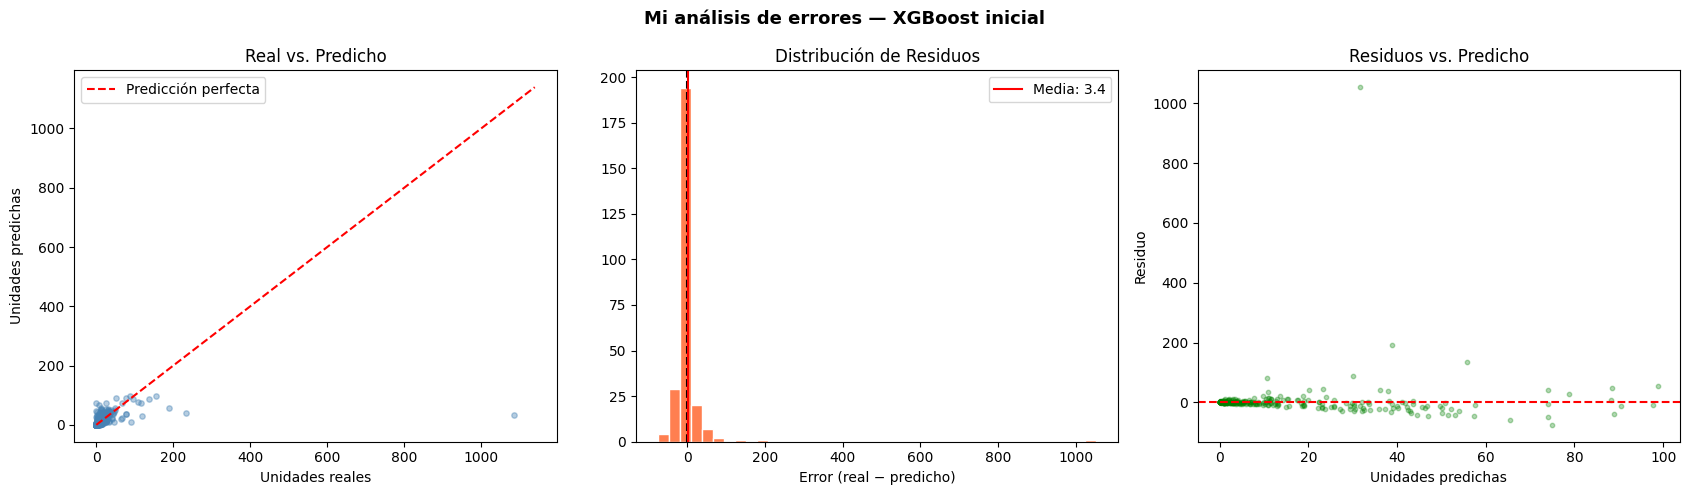

Media residuos: 3.43  |  Std: 69.17
Error < 5 unidades:  53.7%
Error < 10 unidades: 68.3%


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Gráfico de dispersión: valores reales vs. predichos
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
lim = max(float(y_test.max()), float(y_pred.max())) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Unidades reales')
axes[0].set_ylabel('Unidades predichas')
axes[0].set_title('Real vs. Predicho')
axes[0].legend()

# Histograma de los residuos
residuos = y_test.values - y_pred
axes[1].hist(residuos, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(np.mean(residuos), color='red', linewidth=1.5,
                label=f'Media: {np.mean(residuos):.1f}')
axes[1].set_xlabel('Error (real − predicho)')
axes[1].set_title('Distribución de Residuos')
axes[1].legend()

# Residuos vs. valores predichos
axes[2].scatter(y_pred, residuos, alpha=0.3, s=10, color='green')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Unidades predichas')
axes[2].set_ylabel('Residuo')
axes[2].set_title('Residuos vs. Predicho')

plt.suptitle('Mi análisis de errores — XGBoost inicial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Media residuos: {np.mean(residuos):.2f}  |  Std: {np.std(residuos):.2f}")
print(f"Error < 5 unidades:  {(np.abs(residuos) < 5).mean()*100:.1f}%")
print(f"Error < 10 unidades: {(np.abs(residuos) < 10).mean()*100:.1f}%")

### 7.2 Error por producto

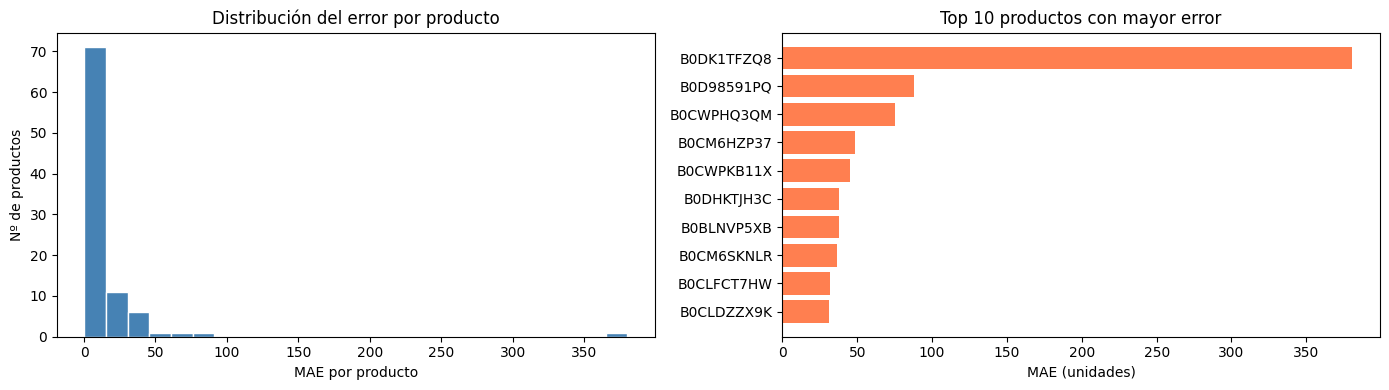

In [19]:
res_test = test[['ASIN (child)', 'fecha', 'target_t1']].copy()
res_test['pred']  = y_pred
res_test['error'] = np.abs(res_test['target_t1'] - res_test['pred'])

mae_por_asin = (
    res_test.groupby('ASIN (child)')['error']
    .mean().sort_values(ascending=False).reset_index()
    .rename(columns={'error': 'MAE'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(mae_por_asin['MAE'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE por producto')
axes[0].set_ylabel('Nº de productos')
axes[0].set_title('Distribución del error por producto')

top10 = mae_por_asin.head(10)
axes[1].barh(top10['ASIN (child)'], top10['MAE'], color='coral')
axes[1].set_xlabel('MAE (unidades)')
axes[1].set_title('Top 10 productos con mayor error')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 7.3 Serie temporal de un producto

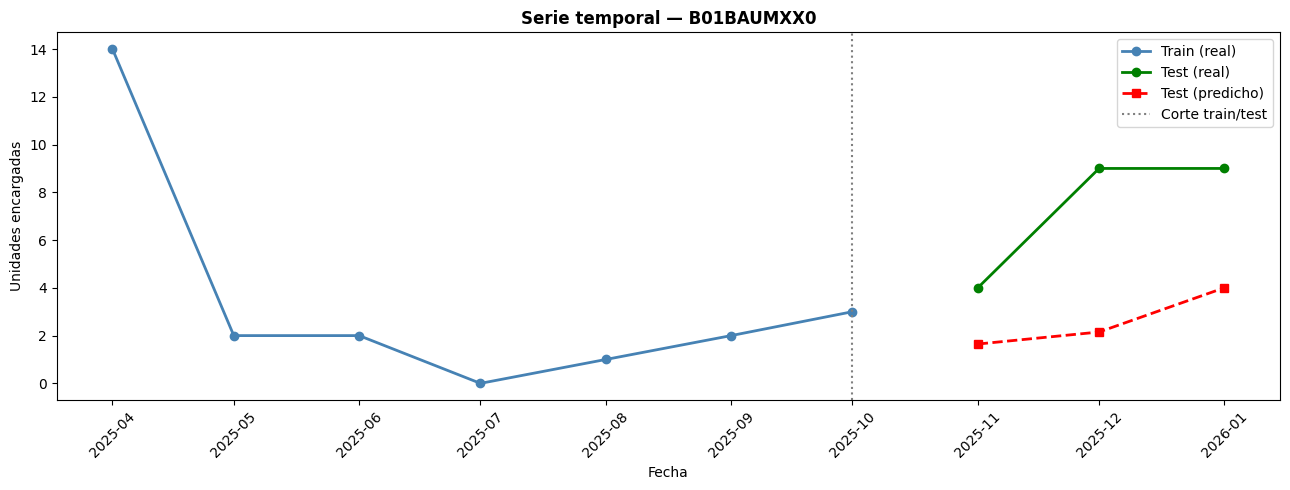

In [12]:
asin_ej = test.groupby('ASIN (child)')['fecha'].count().idxmax()
mask_te = test['ASIN (child)'] == asin_ej
mask_tr = train['ASIN (child)'] == asin_ej

pred_ej = y_pred[test.index.get_indexer(test.loc[mask_te].index)]

plt.figure(figsize=(13, 5))
plt.plot(train.loc[mask_tr, 'fecha'], train.loc[mask_tr, 'target_t1'],
         marker='o', color='steelblue', label='Train (real)', linewidth=2)
plt.plot(test.loc[mask_te, 'fecha'], y_test[mask_te].values,
         marker='o', color='green', label='Test (real)', linewidth=2)
plt.plot(test.loc[mask_te, 'fecha'], pred_ej,
         marker='s', linestyle='--', color='red', label='Test (predicho)', linewidth=2)
plt.axvline(fecha_corte, color='gray', linestyle=':', linewidth=1.5, label='Corte train/test')
plt.title(f'Serie temporal — {asin_ej}', fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Unidades encargadas')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 7.4 Importancia de variables

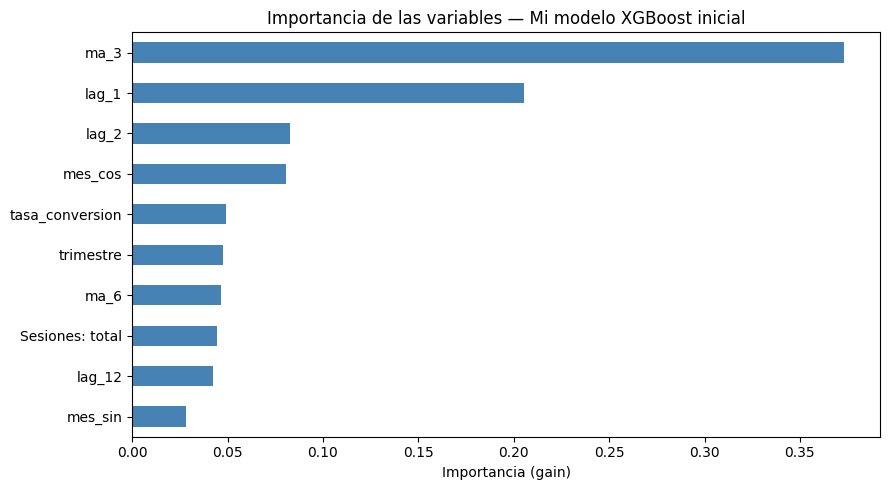

In [13]:
pd.Series(model.feature_importances_, index=feature_cols).sort_values().plot(
    kind='barh', figsize=(9, 5), color='steelblue',
    title='Importancia de las variables — Mi modelo XGBoost inicial'
)
plt.xlabel('Importancia (gain)')
plt.tight_layout()
plt.show()

## 8. Optimización de Hiperparámetros

### 8.1 Validación cruzada temporal (TimeSeriesSplit)

Realizo una validación con 5 folds, respetando siempre el orden cronológico; el conjunto de test siempre será posterior al de train.

In [14]:
X_cv = df_model[feature_cols]
y_cv = df_model['target_t1']
tscv = TimeSeriesSplit(n_splits=5)

scores_mae, scores_r2 = [], []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_cv), 1):
    m = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, n_jobs=-1, verbosity=0)
    m.fit(X_cv.iloc[tr_idx], y_cv.iloc[tr_idx])
    p = np.maximum(m.predict(X_cv.iloc[val_idx]), 0)
    scores_mae.append(mean_absolute_error(y_cv.iloc[val_idx], p))
    scores_r2.append(r2_score(y_cv.iloc[val_idx], p))
    print(f"  Fold {fold}:  MAE = {scores_mae[-1]:.2f}  |  R² = {scores_r2[-1]:.4f}")

print(f"\n  Mi media →  MAE = {np.mean(scores_mae):.2f} ± {np.std(scores_mae):.2f}  |  R² = {np.mean(scores_r2):.4f}")

  Fold 1:  MAE = 2.35  |  R² = 0.6778
  Fold 2:  MAE = 7.01  |  R² = 0.4399
  Fold 3:  MAE = 8.24  |  R² = 0.7230
  Fold 4:  MAE = 8.57  |  R² = 0.1618
  Fold 5:  MAE = 24.19  |  R² = 0.0344

  Mi media →  MAE = 10.07 ± 7.40  |  R² = 0.4074


### 8.2 RandomizedSearchCV — búsqueda de hiperparámetros

Realizo una búsqueda de hiperparámetros con 50 combinaciones aleatorias, utilizando validación cruzada temporal. Considero que es un método más eficiente que GridSearch.

In [15]:
param_grid = {
    'n_estimators':     [200, 300, 500, 700],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'max_depth':        [3, 4, 5, 6, 7],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0, 0.1, 0.2, 0.5],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_grid,
    n_iter=50, cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_cv, y_cv)

print("\n── Mis mejores hiperparámetros ──────────────────────────────")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\n  MAE de mi CV: {-search.best_score_:.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

── Mis mejores hiperparámetros ──────────────────────────────
  subsample: 0.6
  n_estimators: 300
  min_child_weight: 1
  max_depth: 4
  learning_rate: 0.01
  gamma: 0.1
  colsample_bytree: 0.6

  MAE de mi CV: 9.52


### 8.3 Reentreno el modelo con los mejores parámetros

In [16]:
model_opt = XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1, verbosity=0)
model_opt.fit(X_train, y_train)

y_pred_opt = np.maximum(model_opt.predict(X_test), 0)

mae_opt  = mean_absolute_error(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2_opt   = r2_score(y_test, y_pred_opt)

print(f"XGBoost opt →  MAE: {mae_opt:.2f}  |  RMSE: {rmse_opt:.2f}  |  R²: {r2_opt:.4f}")
print(f"Mejora total sobre baseline (MAE): {(mae_base - mae_opt) / mae_base * 100:+.1f}%")
res_opt = dict(modelo='XGBoost optimizado', MAE=mae_opt, RMSE=rmse_opt, R2=r2_opt)


XGBoost opt →  MAE: 14.86  |  RMSE: 69.48  |  R²: 0.0767
Mejora total sobre baseline (MAE): +34.9%


## 9. Comparativa Final — Los 3 Modelos

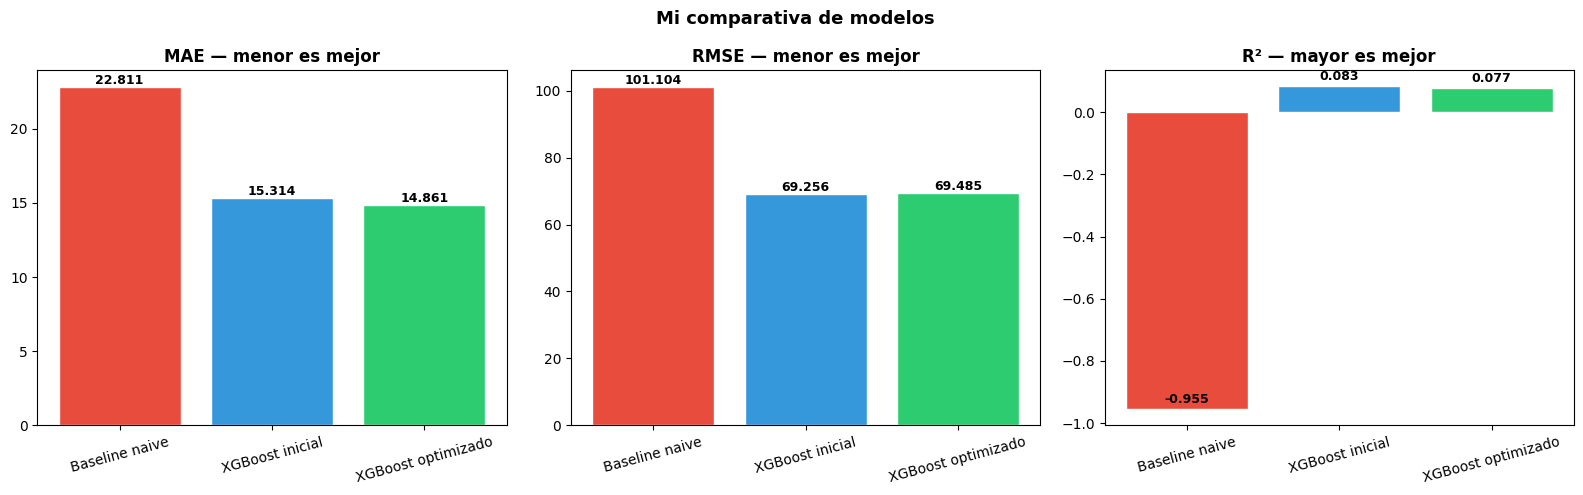

,modelo,MAE,RMSE,R2
0,Baseline naive,22.8108,101.1045,-0.9548
1,XGBoost inicial,15.3141,69.2556,0.0828
2,XGBoost optimizado,14.8610,69.4848,0.0767


In [17]:
df_comp = pd.DataFrame([res_base, res_xgb, res_opt])
colores  = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, met, tit in zip(axes,
    ['MAE', 'RMSE', 'R2'],
    ['MAE — menor es mejor', 'RMSE — menor es mejor', 'R² — mayor es mejor']):
    bars = ax.bar(df_comp['modelo'], df_comp[met], color=colores, edgecolor='white')
    ax.set_title(tit, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, df_comp[met]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Mi comparativa de modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(df_comp.round(4))

## 10. Derivo las Ventas en € y Guardo los resultados

In [18]:
# Calculo el ticket medio por ASIN (solo con datos de train)
ticket_medio = (
    train.groupby('ASIN (child)')
    .apply(lambda x:
        x['Ventas de productos encargados'].sum() /
        x['Unidades encargadas'].replace(0, np.nan).sum()
    ).rename('ticket_medio').reset_index()
)

resultados = test[['ASIN (child)', 'fecha', 'target_t1']].copy()
resultados['pred_unidades'] = y_pred_opt
resultados = resultados.merge(ticket_medio, on='ASIN (child)', how='left')
resultados['pred_ventas_eur'] = resultados['pred_unidades'] * resultados['ticket_medio']

print("Muestra de predicciones finales:")
display(resultados[['ASIN (child)', 'fecha', 'target_t1',
                     'pred_unidades', 'pred_ventas_eur']].head(10).round(2))

# Guardar
resultados.to_csv('/content/drive/MyDrive/DatasetAmazon/predicciones_finales.csv', index=False)
df_comp.to_csv('/content/drive/MyDrive/DatasetAmazon/metricas_comparativa.csv', index=False)
with open('/content/drive/MyDrive/DatasetAmazon/modelo_xgb_optimizado.pkl', 'wb') as f:
    pickle.dump(model_opt, f)

print("\nHe guardado los siguientes archivos: predicciones_finales.csv · metricas_comparativa.csv · modelo_xgb_optimizado.pkl")

Muestra de predicciones finales:


/tmp/ipykernel_12124/4124377393.py:5: RuntimeWarning: invalid value encountered in scalar divide
  x['Ventas de productos encargados'].sum() /
/tmp/ipykernel_12124/4124377393.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:


,ASIN (child),fecha,target_t1,pred_unidades,pred_ventas_eur
0,B01BAUMXX0,2025-11-01,4.0,2.81,39.32
1,B01BAUMXX0,2025-12-01,9.0,3.36,47.00
2,B01BAUMXX0,2026-01-01,9.0,5.10,71.35
3,B01BAUN85C,2025-11-01,3.0,2.08,29.13
4,B01BAUN85C,2025-12-01,11.0,2.82,39.43
5,B01BAUN85C,2026-01-01,15.0,9.03,126.39
6,B01BAUNE6K,2025-11-01,0.0,1.72,17.20
7,B01BAUNE6K,2025-12-01,0.0,5.54,55.40
8,B01BAUNE6K,2026-01-01,0.0,4.42,44.24
9,B01BAUNIUC,2025-11-01,0.0,5.52,55.18



He guardado los siguientes archivos: predicciones_finales.csv · metricas_comparativa.csv · modelo_xgb_optimizado.pkl
